In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\kartik chauhan\bank_loan_cleaned.csv")

In [3]:
# change target column value in int 
df['default_binary'] = (df['default'] == 'Yes').astype(int)
df['default_binary'].value_counts()

default_binary
0    3025
1    1975
Name: count, dtype: int64

In [4]:
features = ['age', 'monthly_income', 'credit_score', 'loan_amount', 'loan_term_months',
'existing_loans', 'num_dependents', 'late_payments_last_year', 'debt_to_income_ratio']

cat_features = ['gender', 'marital_status', 'employment_type', 'loan_type', 'home_ownership']

X = df[features].copy()

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(df[col])
    le_dict[col] = le

y = df['default_binary']

In [5]:
# testing and spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (4000, 14) Test size: (1000, 14)


In [6]:
# train the model
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# predict the acc score
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.717
ROC-AUC: 0.7504885448268648

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.90      0.79       605
           1       0.74      0.44      0.55       395

    accuracy                           0.72      1000
   macro avg       0.72      0.67      0.67      1000
weighted avg       0.72      0.72      0.70      1000



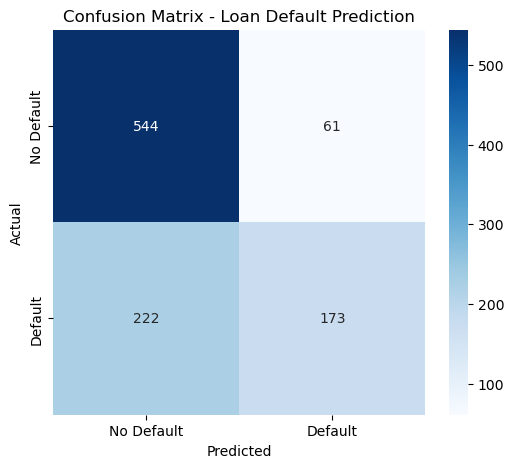

In [8]:
# confusion metrics plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default','Default'], yticklabels=['No Default','Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Loan Default Prediction')
plt.savefig('confusion_matrix.png')
plt.show()

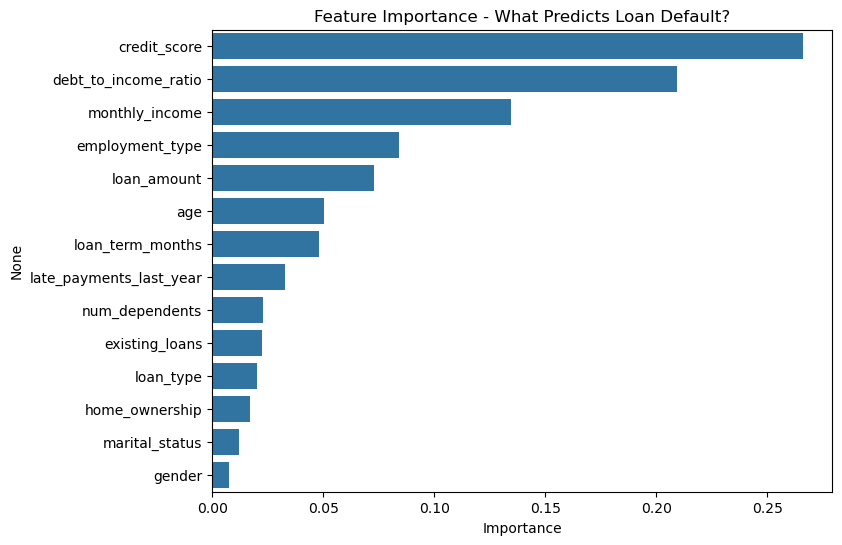

credit_score               0.265892
debt_to_income_ratio       0.209413
monthly_income             0.134412
employment_type            0.084037
loan_amount                0.072749
age                        0.050153
loan_term_months           0.048164
late_payments_last_year    0.032869
num_dependents             0.022909
existing_loans             0.022668
loan_type                  0.020226
home_ownership             0.017195
marital_status             0.011873
gender                     0.007438
dtype: float64


In [9]:
# Feature Importance plot
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title('Feature Importance - What Predicts Loan Default?')
plt.xlabel('Importance')
plt.savefig('feature_importance.png')
plt.show()

print(importance)